# A deep dive into robomimic datasets

This notebook will provide examples on how to work with robomimic datasets through various python code examples. This notebook assumes that you have installed `robomimic` and `robosuite` (which should be on the `offline_study` branch).

## Download dataset

First, let's try downloading a simple dataset - we'll use the Lift (PH) dataset. Note that there are utility scripts such as `scripts/download_datasets.py` to do this for us, but for the purposes of this example, we'll use our class' pre-segmented datasets.

In [ ]:
import os
# First, we need to decide where to host the runtime storage
USE_GDRIVE_STORAGE = True

if not USE_GDRIVE_STORAGE:
    # Option 1: use the colab runtime storage. All trained model and downloaded
    # will disappear after you disconnect from the runtime.
    WS_DIR = "/content/"
else:
    # Option 2: use your google drive as the runtime storage. You need to grant
    # permission for the colab runtime to access your google drive. You also
    # need to decide on a workspace for robomimic. In this case, we've created a
    # folder called "colab_ws" in Google Drive.
    from google.colab import drive
    drive.mount('/content/drive')
    WS_DIR = "/content/drive/MyDrive/colab_ws/" # this should be the absolute path, e.g., "/content/drive/MyDrive/my-ws/"
    assert os.path.exists(WS_DIR)

%cd $WS_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/colab_ws


In [ ]:
# Install the basic requirements
# %cd $WS_DIR
!pip install -e robosuite/
!pip install -e robomimic/
!pip install -e mimicgen_environments/
!pip install -e mujoco

import sys
import os
sys.path.append('./robosuite/')
sys.path.append('./robomimic/')
sys.path.append('./mimicgen_environments/')
sys.path.append('/content/drive/MyDrive/colab_ws/robomimic/robomimic/algo/')

Obtaining file:///content/drive/MyDrive/colab_ws/robosuite
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for robosuite (pyproject.toml) ... done
  Created wheel for robosuite: filename=robosuite-1.4.1-0.editable-py3-none-any.whl size=6967 sha256=9cd764ee211f5e7c2658c92e20fd8b02c1b7047b54b9ac4d33a83c79c1c1394c
  Stored in directory: /tmp/pip-ephem-wheel-cache-c0togvjz/wheels/07/97/34/c35a2d0b7f1dab8a60b73d241ad0302d7d627ab89e6a23c480
Successfully built robosuite
  Attempting uninstall: robosuite
    Found existing installation: robosuite 1.4.1
    Uninstalling robosuite-1.4.1:
      Successfully uninstalled robosuite-1.4.1
Obtaining file:///content/drive/MyDrive/colab_ws/robomimic
  Preparing metadata (setup.py) ... done
  Attempting uninstall: robomimic
    Found existing installation: robomimic 0.3.0
    U

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now it's time to download some datasets. You can download the full dataset for stack_d0 using this command:


```
python download_datasets.py --dataset_type core --tasks stack_d0 --download_dir $DATA_DIR
```

But, this is a large file (~3GB) containing 1000 demonstrations. In the interest of not overreaching our Google Drive quotas, let's instead use some [pre-segmented datasets](https://drive.google.com/drive/folders/121aouiwC5U-pcrqTVt7QWnQgA1GE4Fzc?usp=drive_link), where each segment contains just 100 demonstration. That way we can download just as many (or as few) demonstrations as we need. This link provides us with the first 100 demonstrations of the stack_d0 task:

In [ ]:
import os

# Get the list of all items in the current directory
all_items = os.listdir()

# Filter the list to only include directories
directories = [item for item in all_items if os.path.isdir(item)]

# Print the directories
print("Folders in current directory:", directories)


Folders in current directory: ['robosuite', 'robomimic', 'mimicgen_environments', 'robomimic_data', 'mimicgen_data', 'pydmps', '.ipynb_checkpoints', 'geometry_msgs', 'nav_msgs', 'ros_dmp', 'srv', 'gripD0100Default']


In [ ]:

DATA_DIR = WS_DIR + "/mimicgen_data/"
import mimicgen_envs.utils.file_utils as FileUtils
FileUtils.download_url_from_gdrive(
                url="https://drive.google.com/file/d/1o2LbBglyY7AtsAs4GqTQ15LH4_cqJFmP",
                download_dir=DATA_DIR,
                check_overwrite=True,
            )

Downloading...
From: https://drive.google.com/file/d/1o2LbBglyY7AtsAs4GqTQ15LH4_cqJFmP
To: /tmp/tmp9q4zbzzc/1o2LbBglyY7AtsAs4GqTQ15LH4_cqJFmP
86.5kB [00:00, 32.8MB/s]


y


In [ ]:
import json
import h5py
import numpy as np


# enforce that the dataset exists
dataset_path = os.path.join(DATA_DIR, "stack_d0_100.hdf5")
assert os.path.exists(dataset_path)

**STOP HERE**

## Read quantities from dataset

Next, let's demonstrate how to read different quantities from the dataset. There are scripts such as `scripts/get_dataset_info.py` that can help you easily understand the contents of a dataset, but in this example, we'll break down how to do this directly.

First, let's take a look at the number of demonstrations in the file.

In [ ]:
# open file
dataset_path = '/content/drive/MyDrive/colab_ws//robomimic_data/low_dim_v141.hdf5'
dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d0_100.hdf5'
f = h5py.File(dataset_path, "r")

# each demonstration is a group under "data"
demos = list(f["data"].keys())
num_demos = len(demos)

print("hdf5 file {} has {} demonstrations".format(dataset_path, num_demos))

Next, let's list all of the demonstrations, along with the number of state-action pairs in each demonstration.

In [ ]:
# each demonstration is named "demo_#" where # is a number.
# Let's put the demonstration list in increasing episode order
inds = np.argsort([int(elem[5:]) for elem in demos])
demos = [demos[i] for i in inds]

for ep in demos:
    num_actions = f["data/{}/actions".format(ep)].shape[0]
    print("{} has {} samples".format(ep, num_actions))

f.close()

Now, let's dig into a single trajectory to take a look at some of the quantities in each demonstration.

In [ ]:
!pip install matplotlib

In [ ]:
import random
import matplotlib.pyplot as plt

for t in range(len(demo_grp['obs']['object'][0])):
    col = [array[t] for array in demo_grp['obs']['object']]
    timesteps = list(range(len(col)))





    x_values = timesteps
    y_values = col  # y-values are the observations

    plt.figure(figsize=(10, 6))  # Create a new figure for each graph
    plt.plot(x_values, y_values, 'bo-')  # Plot with blue dots and lines
    plt.title(f"Observations for Object {t}")
    plt.xlabel('t (index)')
    plt.ylabel('Observation Value')
    plt.ylim(min(col), max(col))  # Adjust the y-axis limits based on your data
    plt.grid(True)
    plt.show()

In [ ]:
# look at first demonstration
demo_key = demos[0]
demo_grp = f["data/{}".format(demo_key)]

# Each observation is a dictionary that maps modalities to numpy arrays, and
# each action is a numpy array. Let's print the observation modalities and look at
# the action taken in the first 5 timesteps of this trajectory.
print(demo_grp)

print("observation modalities:")
print(demo_grp["obs"].keys())
#print(demo_grp["next_obs"].keys())

for t in range(10):
  # print("timestep" + str(t) + ":")
  # print(demo_grp["obs"]["robot0_eef_pos"][t])
  # print(demo_grp["obs"]["robot0_joint_pos"][t])
  # # for i in range(len(demo_grp['obs']['object'][t])):
  # #   print(demo_grp['obs']['object'][t][i])
  # print(demo_grp["obs"]["object"][t][0])
  print(demo_grp["actions"][t])

In [ ]:
# we can also grab multiple timesteps at once directly, or even the full trajectory at once
first_ten_actions = demo_grp["actions"][:10]
print("shape of first ten actions {}".format(first_ten_actions.shape))
all_actions = demo_grp["actions"][:]
print("shape of all actions {}".format(all_actions.shape))
print(type(all_actions))

In [ ]:
# we also have "done" and "reward" information stored in each trajectory.
# In this case, we have sparse rewards that indicate task completion at
# that timestep.
dones = demo_grp["dones"][:]
rewards = demo_grp["rewards"][:]
print("dones")
print(dones)
print("")
print("rewards")
print(rewards)

In [ ]:
# each demonstration also contains metadata
num_samples = demo_grp.attrs["num_samples"] # number of samples in this trajectory
mujoco_xml_file = demo_grp.attrs["model_file"] # mujoco XML file for this demonstration
print(type(num_samples))

Finally, let's take a look at some global metadata present in the file. The hdf5 file stores environment metadata which is a convenient way to understand which simulation environment (task) the dataset was collected on.

In [ ]:
env_meta = json.loads(f["data"].attrs["env_args"])
print(type(env_meta))
# note: we could also have used the following function:
# env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
print("==== Env Meta ====")
print(type(json.dumps(env_meta, indent=4)))
print("")

## Visualizing demonstration trajectories

Finally, let's play some of these demonstrations back in the simulation environment to easily visualize the data that was collected.

It turns out that the environment metadata stored in the hdf5 allows us to easily create a simulation environment that is consistent with the way the dataset was collected!

In [ ]:
import robomimic.utils.env_utils as EnvUtils

# create simulation environment from environment metedata
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,            # no on-screen rendering
    render_offscreen=True,   # off-screen rendering to support rendering video frames
)

In [ ]:
import robomimic.utils.obs_utils as ObsUtils
print(type(env))

# We normally need to make sure robomimic knows which observations are images (for the
# data processing pipeline). This is usually inferred from your training config, but
# since we are just playing back demonstrations, we just need to initialize robomimic
# with a dummy spec.
dummy_spec = dict(
    obs=dict(
            low_dim=["robot0_eef_pos"],
            rgb=[],
        ),
)

print(type(dummy_spec))
ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)

In [ ]:
import imageio

# prepare to write playback trajectories to video
video_path = os.path.join(DATA_DIR, "playback.mp4")
video_writer = imageio.get_writer(video_path, fps=20)

print(type(video_path))
print(type(video_writer))

In [ ]:
from ssl import ALERT_DESCRIPTION_ACCESS_DENIED
def playback_trajectory(demo_key):
    """
    Simple helper function to playback the trajectory stored under the hdf5 group @demo_key and
    write frames rendered from the simulation to the active @video_writer.
    """

    # robosuite datasets store the ground-truth simulator states under the "states" key.
    # We will use the first one, alone with the model xml, to reset the environment to
    # the initial configuration before playing back actions.
    init_state = f["data/{}/states".format(demo_key)][0]
    model_xml = f["data/{}".format(demo_key)].attrs["model_file"]
    initial_state_dict = dict(states=init_state, model=model_xml)

    # reset to initial state
    env.reset_to(initial_state_dict)

    # playback actions one by one, and render frames
    actions = f["data/{}/actions".format(demo_key)][:]
    print("Actions are ", actions.shape)
    print("Actions shape 0 ", actions.shape[0])
    print("actions timestep ", actions[0])
    print("actions timestep ", type(actions[0]))
    for t in range(actions.shape[0]):
         x = env.step(actions[t])
         video_img = env.render(mode="rgb_array", height=512, width=512, camera_name="agentview")
         video_writer.append_data(video_img)
         print("X is ", x[0])
         print("X type is ", type(x[0]))

In [ ]:
# playback the first 3 demos and record them to a video file
for ep in demos[:1]:
    print("Playing back demo key: {}".format(ep))
    playback_trajectory(ep)

# done writing video
video_writer.close()

In [ ]:
# view the trajectories!
from IPython.display import Video
Video(video_path, embed=True)

**START HERE! JUST RUN EVERYTHING STARTING WITH THIS BLOCK OF CODE**

In [ ]:
# import all utility functions

import numpy as np

import torch
from torch.utils.data import DataLoader

import robomimic
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.torch_utils as TorchUtils
import robomimic.utils.test_utils as TestUtils
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.train_utils as TrainUtils
from robomimic.utils.dataset import SequenceDataset

from robomimic.config import config_factory
from robomimic.algo import algo_factory

import torch.distributions as D
import copy


In [ ]:
def get_example_model(dataset_path, device):
    """
    Use a default config to construct a BC model.
    """

    # default BC config
    config = config_factory(algo_name="bc")

    # read config to set up metadata for observation modalities (e.g. detecting rgb observations)
    ObsUtils.initialize_obs_utils_with_config(config)

    # read dataset to get some metadata for constructing model
    # all_obs_keys determines what observations we will feed to the policy
    shape_meta = FileUtils.get_shape_metadata_from_dataset(
        dataset_path=dataset_path,
        all_obs_keys=sorted((
            "robot0_eef_pos",  # robot end effector position
            "robot0_eef_quat",   # robot end effector rotation (in quaternion)
            "robot0_gripper_qpos",   # parallel gripper joint position
            "object",  # object information
        )),
    )
    print(shape_meta["ac_dim"])
    # make BC model
    print("FUCK YEAH")
    model = algo_factory(
        algo_name=config.algo_name,
        config=config,
        obs_key_shapes=shape_meta["all_shapes"],
        ac_dim=shape_meta["ac_dim"],
        device=device,
    )
    return model

LoadFile

In [ ]:
dataset_path = '/content/drive/MyDrive/colab_ws//robomimic_data/low_dim_v141.hdf5'
dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d0_100.hdf5'
# dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d1_100.hdf5'
#dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/coffee_d0_100.hdf5'
# dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/coffee_d1_100.hdf5'
#dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d0_500.hdf5"
# dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d1_300.hdf5"
# dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/kitchen_d1_100.hdf5"

In [ ]:
device = TorchUtils.get_torch_device(try_to_use_cuda=True)
print("A")
model = get_example_model(dataset_path, device=device)

print(model)

A

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'object', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
7
FUCK YEAH
ObservationKeyToModalityDict: action not found, adding action to mapping with assumed low_dim modality!
BC (
  ModuleDict(
    (policy): ActorNetwork(
        action_dim=7
  
        encoder=ObservationGroupEncoder(
            group=obs
            ObservationEncoder(
                Key(
                    name=object
                    shape=[23]
                    modality=low_dim
                    randomizer=None
                    net=None
                    sharing_from=None
                )
                Key(
                    name=robot0_eef_pos
                    shape=[3]
                    modality=low_dim
                    randomizer=None
         

In [ ]:
def truncate_batch(batch, length=50):
    """
    Creates a copy of the batch with only the first `length` elements from each dictionary.

    Args:
        batch (dict): A dictionary where each key corresponds to a list or tensor of length 100.
        length (int): The number of elements to keep from the start of each list/tensor. Default is 50.

    Returns:
        truncated_batch (dict): A new dictionary with truncated lists/tensors.
    """
    truncated_batch = {}


    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            truncated_batch[key] = value[:length]  # Truncate tensor
        elif isinstance(value, list):
            truncated_batch[key] = value[:length]  # Truncate list
        elif isinstance(value, dict): #for nested obs dict
            truncated_batch[key] = {}
            for subKey, subValue in value.items():
                truncated_batch[key][subKey] = subValue[:length]  # Truncate nested dictionary

    return truncated_batch

In [ ]:
"""
WARNING: This code snippet is only for instructive purposes, and is missing several useful
         components used during training such as logging and rollout evaluation.
"""
from robomimic.algo import RolloutPolicy
from robomimic.utils.train_utils import run_rollout
def get_data_loader(dataset_path):
    """
    Get a data loader to sample batches of data.
    Args:
        dataset_path (str): path to the dataset hdf5
    """
    dataset = SequenceDataset(
        hdf5_path=dataset_path,
        obs_keys=(                      # observations we want to appear in batches
            "robot0_eef_pos",
            "robot0_eef_quat",
            "robot0_gripper_qpos",
            "object",
        ),
        dataset_keys=(                  # can optionally specify more keys here if they should appear in batches
            "actions",
            "rewards",
            "dones",
        ),
        load_next_obs=False, #SET BACK TO TRUE LATER JSUT FOR TESTING!!!!
        frame_stack=1,
        seq_length=131,                  # Using length 10 takes less time but using a longer lenght gives training sequence...
        pad_frame_stack=True,            #More input on what the robot is supposed to do late in trajectory
        pad_seq_length=True,            # pad last obs per trajectory to ensure all sequences are sampled
        get_pad_mask=False,
        goal_mode=None,
        hdf5_cache_mode="all",          # cache dataset in memory to avoid repeated file i/o
        hdf5_use_swmr=True,
        hdf5_normalize_obs=False,
        filter_by_attribute=None,       # can optionally provide a filter key here
    )
    print("\n============= Created Dataset =============")
    print(dataset)
    print("")

    data_loader = DataLoader(
        dataset=dataset,
        sampler=None,       # no custom sampling logic (uniform sampling)
        batch_size=100,     # batches of size 100
        shuffle=True,
        num_workers=0,
        drop_last=True      # don't provide last batch in dataset pass if it's less than 100 in size
    )
    return data_loader


def run_train_loop(model, data_loader, num_epochs=50, gradient_steps_per_epoch=100):
    """
    Note: this is a stripped down version of @TrainUtils.run_epoch and the train loop
    in the train function in train.py. Logging and evaluation rollouts were removed.
    Args:
        model (Algo instance): instance of Algo class to use for training
        data_loader (torch.utils.data.DataLoader instance): torch DataLoader for
            sampling batches
    """
    # ensure model is in train mode
    model.set_train()

    #create environment required to generate trajectories
    #env = model.createEnvironment(dataset_path)

    lossOverTime = []

    for epoch in range(1, num_epochs + 1): # epoch numbers start at 1

        # iterator for data_loader - it yields batches
        data_loader_iter = iter(data_loader)

        # record losses
        losses = []

        #Generate Trajecories to use to train the discriminator on
        # generatedTrajectory = model.generateTrajectory(env)

        # #used to compute values required for TRPO rule
        # advantages = model.compute_advantages(generatedTrajectory)

        # # #Env.step requires numpy arrays but torch.utils.backprop requires tensors
        # # #So you need to make a copy of the dict of numpys
        # # #And convert it to tensors or else it will crash
        # # #you need to have a different tensorcopy every time you call backprop
        # # #or else it will crash
        # tensor_traj1 = model.convert_to_tensors(generatedTrajectory)
        # tensor_traj2 = model.convert_to_tensors(generatedTrajectory)

        # # Keep old policy intact in case it violates TRPO
        # oldPolicy = copy.deepcopy(model.nets["policy"])

        # #Get distribution for TRPO rule

        # dist = model.nets["policy"].forward_train(obs_dict=tensor_traj1["states"])
        # old_mean = dist.mean.mean(dim=0)
        # old_std = dist.stddev.std(dim=0)
        # old_dist = D.Normal(old_mean, old_std)
        # old_log_probs = old_dist.log_prob(tensor_traj1['actions']).sum(dim=-1)

        for _ in range(gradient_steps_per_epoch):

            # load next batch from data loader
            try:
                batch = next(data_loader_iter)

            except StopIteration:
                # data loader ran out of batches - reset and yield first batch
                data_loader_iter = iter(data_loader)
                batch = next(data_loader_iter)

            #Function to use less data, optional. Comment out if you want to use full batch
            #batch = truncate_batch(batch, length=50)

            # process batch for training
            input_batch = model.process_batch_for_training(batch)

            # forward and backward pass
            info = model.train_on_batch(batch=input_batch, epoch=epoch, validate=False)

            step_log = model.log_info(info)
            losses.append(step_log["Loss"])

        #compute new distribution for TRPO rule
        # newdist = model.nets["policy"].forward_train(obs_dict=tensor_traj2["states"])
        # new_mean = newdist.mean.mean(dim=0)
        # new_std = newdist.stddev.std(dim=0)
        # new_dist = D.Normal(new_mean, new_std)
        # new_log_probs = new_dist.log_prob(tensor_traj2['actions']).sum(dim=-1)
        # ratio = torch.exp(new_log_probs - old_log_probs)
        # #compute surrogate loss
        # surrogate_loss = (ratio * advantages).mean()

        # # Compute KL Divergence
        # kl_divergence = D.kl_divergence(old_dist, new_dist).mean()

        # #TRPO rule
        # if surrogate_loss < 0 and kl_divergence > 0.05:
        #     model.nets["policy"] = oldPolicy

        # do anything model needs to after finishing epoch
        model.on_epoch_end(epoch)

        print("Train Epoch {}: Loss {}".format(epoch, np.mean(losses)))
        lossOverTime.append(np.mean(losses))

    return lossOverTime


In [ ]:

dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d0_100.hdf5'
# dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d1_100.hdf5'
#dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/coffee_d0_100.hdf5"
#dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d0_500.hdf5"
# dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d1_300.hdf5"
# dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/kitchen_d1_100.hdf5"


data_loader = get_data_loader(dataset_path=dataset_path)
model = get_example_model(dataset_path, device)

# run training loop
lossOverTime = run_train_loop(model=model, data_loader=data_loader, num_epochs=2, gradient_steps_per_epoch=100)

SequenceDataset: loading dataset into memory...
100%|██████████| 100/100 [00:00<00:00, 176.18it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 10896/10896 [00:02<00:00, 4120.06it/s]

============= Created Dataset =============
SequenceDataset (
	path=/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d0_100.hdf5
	obs_keys=('robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'object')
	seq_length=131
	filter_key=none
	frame_stack=1
	pad_seq_length=True
	pad_frame_stack=True
	goal_mode=none
	cache_mode=all
	num_demos=100
	num_sequences=10896
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'object', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
7
FUCK YEAH
Train Epoch 1: Loss 0.20602404266595842
Train Epoch 2: Loss 0.1691910780966282


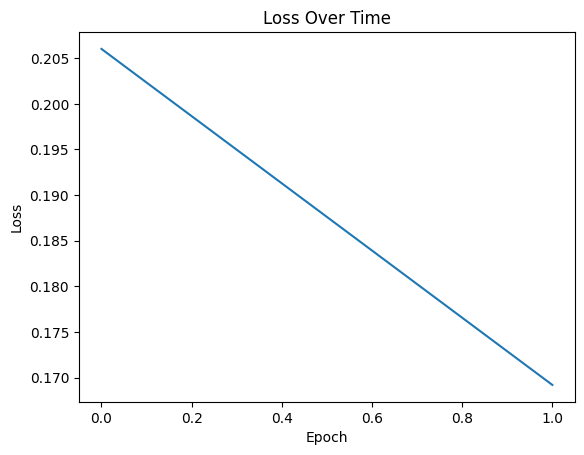

In [ ]:
import matplotlib.pyplot as plt

# Creating the line graph
plt.plot(lossOverTime)

# Adding a title and labels
plt.title('Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Display the graph
plt.show()

In [ ]:
# create simulation environment
import robomimic.utils.env_utils as EnvUtils
dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d0_100.hdf5'
# dataset_path = '/content/drive/MyDrive/colab_ws/mimicgen_data/stack_d1_100.hdf5'
#dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/coffee_d0_200.hdf5"
#dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d0_500.hdf5"
# dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/mug_cleanup_d1_500.hdf5"
# # dataset_path = "/content/drive/MyDrive/colab_ws/mimicgen_data/kitchen_d1_100.hdf5"
env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path)
import robosuite

env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    env_name=env_meta["env_name"],
    render=False,
    render_offscreen=True,
    use_image_obs=False,
)

/usr/local/lib/python3.10/dist-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.10/dist-packages/glfw/__init__.py:914: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: gladLoadGL error

In [ ]:
from robomimic.algo import RolloutPolicy
from robomimic.utils.train_utils import run_rollout
import imageio
import sys


# !chmod -R ugo+rX /content/drive/MyDrive/colab_ws/robosuite/
# !ls -l /content/drive/MyDrive/colab_ws/robosuite/robosuite/
# !pip show robosuite
# !pip install robosuite

from robosuite.scripts import collect_human_demonstrations


# create a thin wrapper around the model to interact with the environment
policy = RolloutPolicy(model)

# create a video writer
video_path = "rollout.mp4"
video_writer = imageio.get_writer(video_path, fps=20)

# run rollout
rollout_log = run_rollout(
    policy=policy,
    env=env,
    horizon=200,
    video_writer=video_writer,
    render=False
)

video_writer.close()
# print rollout results
print(rollout_log)


In [ ]:
# visualize rollout video

from IPython.display import HTML
from base64 import b64encode

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=400 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
from robomimic.algo import RolloutPolicy
from robomimic.utils.train_utils import run_rollout
from robomimic.algo import algo_factory
import imageio
#You can run this but success will always be 0. Sorry I did my best
def evaluate_rollout(model):

    policy = RolloutPolicy(model)

    # create simulation evironment
    env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path)
    env = EnvUtils.create_env_from_metadata(
        env_meta=env_meta,
        env_name=env_meta["env_name"],
        render=False,
        render_offscreen=True,
        use_image_obs=False,
    )

    # create a video writer
    video_path = "rollout.mp4"
    video_writer = imageio.get_writer(video_path, fps=20)

    rollout_log = run_rollout(
        policy=policy,
        env=env,
        horizon=200,
        video_writer=video_writer,
        render=False
    )

    # rollout result
    return rollout_log


def main():

    #model = algo_factory() # load your own model
    #data_loader = get_data_loader(dataset_path = dataset_path) # load your test set
    #losses = evaluate_loss(model, data_loader)
    rollout_result = evaluate_rollout(model)

    print("Success rate is"+str(rollout_result["Success_Rate"]))

if __name__ == "__main__":
    main()